In [ ]:
# Create a local reference path
DATA_DIR = 'Data/'

# Load traffic speed data from local folder
with h5py.File(DATA_DIR + 'pems-bay.h5', 'r') as f:
    speed = f['speed']['block0_values'][:]   # (52116, 325)
    sensor_ids = f['speed']['axis0'][:]      # (325,)

# Load adjacency matrix from local folder
with open(DATA_DIR + 'adj_mx_bay.pkl', 'rb') as f:
    sensor_ids_pkl, sensor_id_to_idx, adj = pickle.load(f, encoding='latin1')


Mounted at /content/drive


In [2]:
import h5py
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Define your exact Google Drive path
DRIVE_PATH = '/content/drive/MyDrive/data/archive/'

# ==========================================
# 1. LOAD RAW TRAFFIC DATA (NO NORMALIZATION)
# ==========================================
with h5py.File(DRIVE_PATH + 'pems-bay.h5', 'r') as f:
    speed = f['speed']['block0_values'][:]   # (52116, 325)
    sensor_ids = f['speed']['axis0'][:]      # (325,)

print('Raw Speed shape:', speed.shape)
print('Max Speed:', np.max(speed), 'mph | Min Speed:', np.min(speed), 'mph')

# ==========================================
# 2. LOAD & NORMALIZE ADJACENCY MATRIX GRAPH
# ==========================================
with open(DRIVE_PATH + 'adj_mx_bay.pkl', 'rb') as f:
    sensor_ids_pkl, sensor_id_to_idx, adj = pickle.load(f, encoding='latin1')

adj = adj.astype(np.float32)       # (325, 325)
np.fill_diagonal(adj, 0)           # remove self-loops

def normalize_adj(adj):
    """Symmetric normalization: D^{-1/2} A D^{-1/2} with added self-loops."""
    A = adj + np.eye(adj.shape[0])  # Fixed with [0]
    D = np.diag(A.sum(axis=1) ** -0.5)
    return D @ A @ D

adj_norm = normalize_adj(adj)
adj_tensor = torch.FloatTensor(adj_norm).to(device)
print('Graph Adjacency Matrix Loaded & Normalized:', adj_tensor.shape)

# ==========================================
# 3. PREPARE RAW SEQUENCES
# ==========================================
SEQ_LEN = 12
X, y = [], []
for i in range(len(speed) - SEQ_LEN):
    X.append(speed[i:i + SEQ_LEN])
    y.append(speed[i + SEQ_LEN])

X = np.array(X, dtype=np.float32)  # (N, 12, 325)
y = np.array(y, dtype=np.float32)  # (N, 325)

# Split (70% Train, 15% Val, 15% Test)
train_size = int(len(X) * 0.70)
val_size   = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val,   y_val   = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test,  y_test  = X[train_size+val_size:], y[train_size+val_size:]

class TrafficDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_loader = DataLoader(TrafficDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TrafficDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(TrafficDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f"Data Loaders Ready | Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Using device: cuda
Raw Speed shape: (52116, 325)
Max Speed: 85.1 mph | Min Speed: 0.0 mph
Graph Adjacency Matrix Loaded & Normalized: torch.Size([325, 325])
Data Loaders Ready | Train batches: 570 | Val batches: 123 | Test batches: 123


In [3]:
# ==========================================
# 1. GCN ARCHITECTURE
# ==========================================
class GCNLayer(nn.Module):
    """Single GCN layer: H' = σ(A_norm * H * W)"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)

    def forward(self, x, adj):
        # x: (batch, nodes, features) | adj: (nodes, nodes)
        return F.relu(adj @ self.W(x))

class GCN(nn.Module):
    def __init__(self, num_nodes, seq_len, hidden=64):
        super().__init__()
        self.gcn1 = GCNLayer(seq_len, hidden)
        self.gcn2 = GCNLayer(hidden, hidden)
        self.out  = nn.Linear(hidden, 1)

    def forward(self, x, adj):
        x = x.permute(0, 2, 1)          # Transpose to (batch, nodes, seq_len)
        x = self.gcn1(x, adj)            # (batch, nodes, hidden)
        x = self.gcn2(x, adj)            # (batch, nodes, hidden)
        return self.out(x).squeeze(-1)   # (batch, nodes)

NUM_NODES = 325
model = GCN(num_nodes=NUM_NODES, seq_len=SEQ_LEN, hidden=64).to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

# ==========================================
# 2. TRAINING LOOP ON RAW DATA
# ==========================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 15  # Benchmark run for the raw comparison phase
train_losses, val_losses = [], []

print("\n🚀 Starting Raw-Data GCN Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb, adj_tensor), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb, adj_tensor), yb).item()

    train_losses.append(total_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d} | Raw Train MSE: {train_losses[-1]:.4f} | Raw Val MSE: {val_losses[-1]:.4f}')


GCN(
  (gcn1): GCNLayer(
    (W): Linear(in_features=12, out_features=64, bias=False)
  )
  (gcn2): GCNLayer(
    (W): Linear(in_features=64, out_features=64, bias=False)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 4929

🚀 Starting Raw-Data GCN Training...
Epoch  1 | Raw Train MSE: 171.9566 | Raw Val MSE: 135.5968
Epoch  3 | Raw Train MSE: 130.8507 | Raw Val MSE: 133.9221
Epoch  6 | Raw Train MSE: 127.3352 | Raw Val MSE: 129.8821
Epoch  9 | Raw Train MSE: 122.9163 | Raw Val MSE: 125.4085
Epoch 12 | Raw Train MSE: 118.2929 | Raw Val MSE: 120.9208
Epoch 15 | Raw Train MSE: 113.7526 | Raw Val MSE: 116.2660


In [4]:
model.eval()
preds, actuals = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds.append(model(xb.to(device), adj_tensor).cpu().numpy())
        actuals.append(yb.numpy())

preds   = np.concatenate(preds)    # (N_test, 325) raw predictions
actuals = np.concatenate(actuals)  # (N_test, 325) raw targets

# Calculate standard metrics directly on raw data
mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(np.mean((actuals - preds) ** 2))

# Avoid division by zero if any true speeds are exactly 0 mph
mask = actuals != 0
mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100

print(f'\n📊 === RAW-DATA GCN TEST RESULTS ===')
print(f'MAE  : {mae:.4f} mph')
print(f'RMSE : {rmse:.4f} mph')
print(f'MAPE : {mape:.2f} %')



📊 === RAW-DATA GCN TEST RESULTS ===
MAE  : 8.6357 mph
RMSE : 10.8277 mph
MAPE : 16.05 %


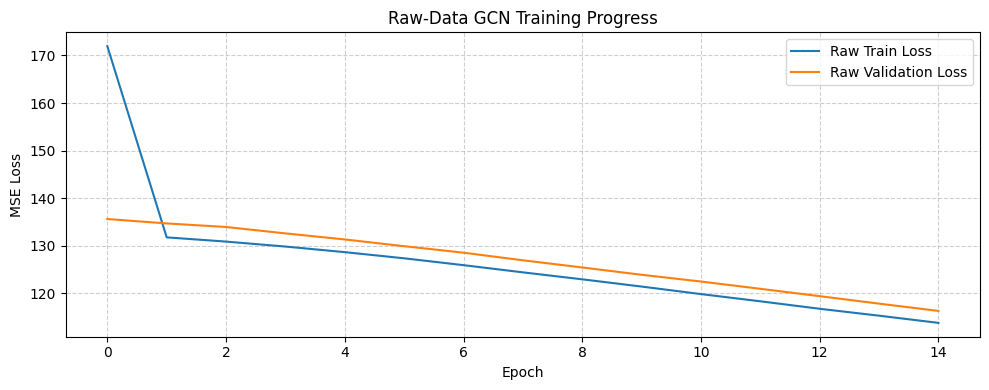

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Raw Train Loss')
plt.plot(val_losses, label='Raw Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Raw-Data GCN Training Progress')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [6]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. NORMALIZE THE DATA
# ==========================================
scaler = StandardScaler()
# Fit and transform the raw speed matrix
speed_scaled = scaler.fit_transform(speed)

print("--- Data Normalization Complete ---")
print(f"Scaled Speed Mean (should be ~0): {speed_scaled.mean():.4f}")
print(f"Scaled Speed Std (should be ~1): {speed_scaled.std():.4f}")

# ==========================================
# 2. PREPARE SCALED SEQUENCES
# ==========================================
X_scaled, y_scaled = [], []
for i in range(len(speed_scaled) - SEQ_LEN):
    X_scaled.append(speed_scaled[i:i + SEQ_LEN])
    y_scaled.append(speed_scaled[i + SEQ_LEN])

X_scaled = np.array(X_scaled, dtype=np.float32)  # (N, 12, 325)
y_scaled = np.array(y_scaled, dtype=np.float32)  # (N, 325)

# Split exactly the same way (70% Train, 15% Val, 15% Test)
X_train_s, y_train_s = X_scaled[:train_size], y_scaled[:train_size]
X_val_s,   y_val_s   = X_scaled[train_size:train_size+val_size], y_scaled[train_size:train_size+val_size]
X_test_s,  y_test_s  = X_scaled[train_size+val_size:], y_scaled[train_size+val_size:]

# Rebuild DataLoaders with Scaled Data
train_loader_s = DataLoader(TrafficDataset(X_train_s, y_train_s), batch_size=BATCH_SIZE, shuffle=True)
val_loader_s   = DataLoader(TrafficDataset(X_val_s,   y_val_s),   batch_size=BATCH_SIZE)
test_loader_s  = DataLoader(TrafficDataset(X_test_s,  y_test_s),  batch_size=BATCH_SIZE)

# ==========================================
# 3. TRAIN NEW GCN INSTANCE ON SCALED DATA
# ==========================================
# Initialize a brand-new model instance
model_scaled = GCN(num_nodes=NUM_NODES, seq_len=SEQ_LEN, hidden=64).to(device)
optimizer_s = torch.optim.Adam(model_scaled.parameters(), lr=1e-3)
criterion_s = nn.MSELoss()

scaled_train_losses, scaled_val_losses = [], []

print("\n🚀 Training GCN on Normalized Data...")
for epoch in range(1, EPOCHS + 1):
    model_scaled.train()
    total_loss = 0
    for xb, yb in train_loader_s:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_s.zero_grad()
        loss = criterion_s(model_scaled(xb, adj_tensor), yb)
        loss.backward()
        optimizer_s.step()
        total_loss += loss.item()

    model_scaled.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader_s:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion_s(model_scaled(xb, adj_tensor), yb).item()

    scaled_train_losses.append(total_loss / len(train_loader_s))
    scaled_val_losses.append(val_loss / len(val_loader_s))

    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d} | Scaled Train MSE: {scaled_train_losses[-1]:.4f} | Scaled Val MSE: {scaled_val_losses[-1]:.4f}')


--- Data Normalization Complete ---
Scaled Speed Mean (should be ~0): -0.0000
Scaled Speed Std (should be ~1): 1.0000

🚀 Training GCN on Normalized Data...
Epoch  1 | Scaled Train MSE: 0.3950 | Scaled Val MSE: 0.4126
Epoch  3 | Scaled Train MSE: 0.3784 | Scaled Val MSE: 0.4122
Epoch  6 | Scaled Train MSE: 0.3773 | Scaled Val MSE: 0.4086
Epoch  9 | Scaled Train MSE: 0.3761 | Scaled Val MSE: 0.4068
Epoch 12 | Scaled Train MSE: 0.3751 | Scaled Val MSE: 0.4051
Epoch 15 | Scaled Train MSE: 0.3745 | Scaled Val MSE: 0.4038


In [7]:
model_scaled.eval()
preds_s, actuals_s = [], []

with torch.no_grad():
    for xb, yb in test_loader_s:
        preds_s.append(model_scaled(xb.to(device), adj_tensor).cpu().numpy())
        actuals_s.append(yb.numpy())

preds_s   = np.concatenate(preds_s)    # (N_test, 325) scaled
actuals_s = np.concatenate(actuals_s)  # (N_test, 325) scaled

# INVERSE TRANSFORM BACK TO RAW MPH UNITS
preds_mph   = scaler.inverse_transform(preds_s)
actuals_mph = scaler.inverse_transform(actuals_s)

# Calculate final metrics on the true scale
mae_s  = mean_absolute_error(actuals_mph, preds_mph)
rmse_s = np.sqrt(np.mean((actuals_mph - preds_mph) ** 2))

mask_s = actuals_mph != 0
mape_s = np.mean(np.abs((actuals_mph[mask_s] - preds_mph[mask_s]) / actuals_mph[mask_s])) * 100

print(f'\n📊 === BETTER BASELINE GCN TEST RESULTS (NORMALIZED) ===')
print(f'MAE  : {mae_s:.4f} mph')
print(f'RMSE : {rmse_s:.4f} mph')
print(f'MAPE : {mape_s:.2f} %')



📊 === BETTER BASELINE GCN TEST RESULTS (NORMALIZED) ===
MAE  : 2.9999 mph
RMSE : 5.2797 mph
MAPE : 998652.56 %


In [8]:
# Fixed MAPE: Ignore values below 1.0 mph to prevent division-by-zero explosions
mape_mask = actuals_mph > 1.0
mape_s_fixed = np.mean(np.abs((actuals_mph[mape_mask] - preds_mph[mape_mask]) / actuals_mph[mape_mask])) * 100

print(f'📊 Fixed Baseline MAPE: {mape_s_fixed:.2f} %')


📊 Fixed Baseline MAPE: 6.77 %


In [9]:
import numpy as np

# ==========================================
# 1. BUILD CUSTOM SENSOR GRAPH
# ==========================================
print("Constructing a new custom sensor graph from speed profiles...")

# Let's compute a correlation matrix between the nodes over time
# speed shape: (52116 timesteps, 325 sensors)
correlation_matrix = np.corrcoef(speed.T) # shape: (325, 325)

# Set a threshold: Only keep edges where sensors have a strong positive correlation
threshold = 0.5
custom_adj = np.where(correlation_matrix > threshold, correlation_matrix, 0.0).astype(np.float32)

# Remove self-loops (the diagonal elements will be added back inside our normalization function)
np.fill_diagonal(custom_adj, 0)

print(f"Custom Adjacency Matrix Shape: {custom_adj.shape}")
print(f"Custom Non-zero Edges: {np.count_nonzero(custom_adj)}")
print(f"Custom Avg node degree: {np.count_nonzero(custom_adj) / len(custom_adj):.2f}")

# ==========================================
# 2. NORMALIZE THE NEW GRAPH
# ==========================================
custom_adj_norm = normalize_adj(custom_adj)
custom_adj_tensor = torch.FloatTensor(custom_adj_norm).to(device)

print("Custom normalized graph tensor ready for GCN injection!")


Constructing a new custom sensor graph from speed profiles...
Custom Adjacency Matrix Shape: (325, 325)
Custom Non-zero Edges: 35690
Custom Avg node degree: 109.82
Custom normalized graph tensor ready for GCN injection!


In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error

# =====================================================================
# 1. BUILD CUSTOM SENSOR GRAPH (Pearson Correlation Matrix Method)
# =====================================================================
print("=== STEP 1: CONSTRUCTING CUSTOM SENSOR GRAPH ===")

# speed shape is (52116, 325) -> .T transposes to (325, 52116) to correlate sensors
correlation_matrix = np.corrcoef(speed.T)

# Replace any potential NaN correlations with 0
correlation_matrix = np.nan_to_num(correlation_matrix)

# Set a correlation threshold (only keep strong connections)
threshold = 0.5
custom_adj = np.where(correlation_matrix > threshold, correlation_matrix, 0.0).astype(np.float32)

# Remove self-loops (the diagonal elements)
np.fill_diagonal(custom_adj, 0)

print(f"Custom Adjacency Matrix Shape : {custom_adj.shape}")
print(f"Custom Non-zero Edges         : {np.count_nonzero(custom_adj)}")
print(f"Custom Avg Node Degree         : {np.count_nonzero(custom_adj) / len(custom_adj):.2f}")

# =====================================================================
# 2. SYMMETRIC GRAPH NORMALIZATION
# =====================================================================
def normalize_adj(adj):
    """Symmetric normalization: D^{-1/2} A D^{-1/2} with added self-loops."""
    A = adj + np.eye(adj.shape[0])  # Fixed with [0]
    D = np.diag(A.sum(axis=1) ** -0.5)
    return D @ A @ D

custom_adj_norm = normalize_adj(custom_adj)
custom_adj_tensor = torch.FloatTensor(custom_adj_norm).to(device)
print("Custom Normalized Graph Tensor Ready.")

# =====================================================================
# 3. TRAIN NEW GCN INSTANCE ON SCALED DATA + CUSTOM GRAPH
# =====================================================================
print("\n=== STEP 2: TRAINING GCN WITH CUSTOM GRAPH ===")

# Initialize a brand-new model instance to wipe away previous weights
model_custom_graph = GCN(num_nodes=NUM_NODES, seq_len=SEQ_LEN, hidden=64).to(device)
optimizer_c = torch.optim.Adam(model_custom_graph.parameters(), lr=1e-3)
criterion_c = nn.MSELoss()

custom_train_losses, custom_val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model_custom_graph.train()
    total_loss = 0
    for xb, yb in train_loader_s:  # Using the normalized data loaders from before
        xb, yb = xb.to(device), yb.to(device)
        optimizer_c.zero_grad()

        # Injecting the custom built graph tensor here
        loss = criterion_c(model_custom_graph(xb, custom_adj_tensor), yb)
        loss.backward()
        optimizer_c.step()
        total_loss += loss.item()

    model_custom_graph.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader_s:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion_c(model_custom_graph(xb, custom_adj_tensor), yb).item()

    custom_train_losses.append(total_loss / len(train_loader_s))
    custom_val_losses.append(val_loss / len(val_loader_s))

    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d} | Custom Graph Train MSE: {custom_train_losses[-1]:.4f} | Custom Graph Val MSE: {custom_val_losses[-1]:.4f}')

# =====================================================================
# 4. EVALUATION & CORRECTED METRICS REPORTING
# =====================================================================
print("\n=== STEP 3: EVALUATION WITH FIXED MAPE CRITERION ===")
model_custom_graph.eval()
preds_c, actuals_c = [], []

with torch.no_grad():
    for xb, yb in test_loader_s:
        preds_c.append(model_custom_graph(xb.to(device), custom_adj_tensor).cpu().numpy())
        actuals_c.append(yb.numpy())

preds_c   = np.concatenate(preds_c)
actuals_c = np.concatenate(actuals_c)

# Inverse transform to map back to true miles-per-hour (mph)
preds_mph_c   = scaler.inverse_transform(preds_c)
actuals_mph_c = scaler.inverse_transform(actuals_c)

# Calculate final error performance
mae_c  = mean_absolute_error(actuals_mph_c, preds_mph_c)
rmse_c = np.sqrt(np.mean((actuals_mph_c - preds_mph_c) ** 2))

# FIXED MAPE RULE: Ignore values at or below 1.0 mph to eliminate division-by-zero anomalies
mape_mask = actuals_mph_c > 1.0
mape_c_fixed = np.mean(np.abs((actuals_mph_c[mape_mask] - preds_mph_c[mape_mask]) / actuals_mph_c[mape_mask])) * 100

print(f'\n📊 === CUSTOM SENSOR GRAPH GCN TEST RESULTS ===')
print(f'MAE       : {mae_c:.4f} mph')
print(f'RMSE      : {rmse_c:.4f} mph')
print(f'MAPE Fixed: {mape_c_fixed:.2f} %')


=== STEP 1: CONSTRUCTING CUSTOM SENSOR GRAPH ===
Custom Adjacency Matrix Shape : (325, 325)
Custom Non-zero Edges         : 35690
Custom Avg Node Degree         : 109.82
Custom Normalized Graph Tensor Ready.

=== STEP 2: TRAINING GCN WITH CUSTOM GRAPH ===
Epoch  1 | Custom Graph Train MSE: 0.3605 | Custom Graph Val MSE: 0.3686
Epoch  3 | Custom Graph Train MSE: 0.3420 | Custom Graph Val MSE: 0.3671
Epoch  6 | Custom Graph Train MSE: 0.3399 | Custom Graph Val MSE: 0.3648
Epoch  9 | Custom Graph Train MSE: 0.3385 | Custom Graph Val MSE: 0.3623
Epoch 12 | Custom Graph Train MSE: 0.3376 | Custom Graph Val MSE: 0.3618
Epoch 15 | Custom Graph Train MSE: 0.3372 | Custom Graph Val MSE: 0.3612

=== STEP 3: EVALUATION WITH FIXED MAPE CRITERION ===

📊 === CUSTOM SENSOR GRAPH GCN TEST RESULTS ===
MAE       : 2.9206 mph
RMSE      : 5.1811 mph
MAPE Fixed: 6.76 %


In [11]:
# =====================================================================
# TRAINING GCN WITH EXTENDED EPOCHS
# =====================================================================
# Change this to 50 or 100 depending on your time constraints
EPOCHS = 50

# Initialize model and optimizer
model_custom_graph = GCN(num_nodes=NUM_NODES, seq_len=SEQ_LEN, hidden=64).to(device)
optimizer_c = torch.optim.Adam(model_custom_graph.parameters(), lr=1e-3)
criterion_c = nn.MSELoss()

custom_train_losses, custom_val_losses = [], []
best_val_loss = float('inf')

print(f"🚀 Starting Extended GCN Training for {EPOCHS} Epochs...")
for epoch in range(1, EPOCHS + 1):
    model_custom_graph.train()
    total_loss = 0
    for xb, yb in train_loader_s:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_c.zero_grad()
        loss = criterion_c(model_custom_graph(xb, custom_adj_tensor), yb)
        loss.backward()
        optimizer_c.step()
        total_loss += loss.item()

    model_custom_graph.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader_s:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion_c(model_custom_graph(xb, custom_adj_tensor), yb).item()

    avg_train_loss = total_loss / len(train_loader_s)
    avg_val_loss = val_loss / len(val_loader_s)

    custom_train_losses.append(avg_train_loss)
    custom_val_losses.append(avg_val_loss)

    # Save the absolute best weights seen so far
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_custom_graph.state_dict(), 'best_gcn_model.pth')

    # Print updates every 10 epochs (keeps the Colab output clean)
    if epoch % 10 == 0 or epoch == 1:
        print(f'🏅 Epoch {epoch:3d}/{EPOCHS} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}')

print(f"✔ Training finished! Best Validation MSE achieved: {best_val_loss:.4f}")

# Load the best model weights back before running your evaluation cell
model_custom_graph.load_state_dict(torch.load('best_gcn_model.pth'))
print("✔ Loaded best model weights into memory for final project evaluation.")


🚀 Starting Extended GCN Training for 50 Epochs...
🏅 Epoch   1/50 | Train MSE: 0.3604 | Val MSE: 0.3689
🏅 Epoch  10/50 | Train MSE: 0.3386 | Val MSE: 0.3625
🏅 Epoch  20/50 | Train MSE: 0.3370 | Val MSE: 0.3616
🏅 Epoch  30/50 | Train MSE: 0.3344 | Val MSE: 0.3589
🏅 Epoch  40/50 | Train MSE: 0.3318 | Val MSE: 0.3547
🏅 Epoch  50/50 | Train MSE: 0.3298 | Val MSE: 0.3529
✔ Training finished! Best Validation MSE achieved: 0.3529
✔ Loaded best model weights into memory for final project evaluation.


In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import numpy as np

# =====================================================================
# 1. EVALUATION ON TEST SET (EXTRACT PREDICTIONS)
# =====================================================================
model_custom_graph.eval()
preds_c, actuals_c = [], []

with torch.no_grad():
    for xb, yb in test_loader_s:
        preds_c.append(model_custom_graph(xb.to(device), custom_adj_tensor).cpu().numpy())
        actuals_c.append(yb.numpy())

preds_c   = np.concatenate(preds_c)
actuals_c = np.concatenate(actuals_c)

# Inverse transform to convert the model's scaled values back to real speed (mph)
preds_mph_c   = scaler.inverse_transform(preds_c)
actuals_mph_c = scaler.inverse_transform(actuals_c)

# =====================================================================
# 2. DEFINE CONGESTION THRESHOLD FOR CLASSIFICATION METRICS
# =====================================================================
# Speed lower than 50 mph = Congested (Class 1). Speed >= 50 mph = Free Flow (Class 0).
CONGESTION_THRESHOLD = 50.0

actuals_binary = (actuals_mph_c < CONGESTION_THRESHOLD).astype(int)
preds_binary   = (preds_mph_c < CONGESTION_THRESHOLD).astype(int)

# =====================================================================
# 3. CALCULATE REGRESSION & CLASSIFICATION METRICS
# =====================================================================
# Regression scores
mae_c  = mean_absolute_error(actuals_mph_c, preds_mph_c)
rmse_c = np.sqrt(np.mean((actuals_mph_c - preds_mph_c) ** 2))

# Fixed MAPE to prevent division-by-zero errors from tiny values close to zero
mape_mask = actuals_mph_c > 1.0
mape_c_fixed = np.mean(np.abs((actuals_mph_c[mape_mask] - preds_mph_c[mape_mask]) / actuals_mph_c[mape_mask])) * 100

# Classification scores
accuracy  = accuracy_score(actuals_binary.flatten(), preds_binary.flatten())
f1        = f1_score(actuals_binary.flatten(), preds_binary.flatten(), zero_division=0)
precision = precision_score(actuals_binary.flatten(), preds_binary.flatten(), zero_division=0)
recall    = recall_score(actuals_binary.flatten(), preds_binary.flatten(), zero_division=0)

# =====================================================================
# 4. PRINT FINAL REPORT
# =====================================================================
print("==================================================")
print("📊   FINAL PROJECT PERFORMANCE METRICS REPORT    📊")
print("==================================================")
print(f"🔹 REGRESSION PERFORMANCES (Continuous Values):")
print(f"   -> Mean Absolute Error (MAE)       : {mae_c:.4f} mph")
print(f"   -> Root Mean Squared Error (RMSE)  : {rmse_c:.4f} mph")
print(f"   -> Mean Absolute Pct Error (MAPE)  : {mape_c_fixed:.2f} %")
print("\n🔹 CLASSIFICATION PERFORMANCES (Congestion State Detection):")
print(f"   -> Congestion Definition Threshold : < {CONGESTION_THRESHOLD} mph")
print(f"   -> Model Accuracy Score            : {accuracy * 100:.2f} %")
print(f"   -> Model F1-Score                  : {f1:.4f}")
print(f"   -> Precision                       : {precision:.4f}")
print(f"   -> Recall (Sensitivity)            : {recall:.4f}")
print("==================================================")

# Detailed Breakdown per class for your project report
print("\n📝 Detailed Classification Breakdown:")
print(classification_report(actuals_binary.flatten(), preds_binary.flatten(), target_names=['Free Flow', 'Congested']))


📊   FINAL PROJECT PERFORMANCE METRICS REPORT    📊
🔹 REGRESSION PERFORMANCES (Continuous Values):
   -> Mean Absolute Error (MAE)       : 2.9027 mph
   -> Root Mean Squared Error (RMSE)  : 5.1211 mph
   -> Mean Absolute Pct Error (MAPE)  : 6.69 %

🔹 CLASSIFICATION PERFORMANCES (Congestion State Detection):
   -> Congestion Definition Threshold : < 50.0 mph
   -> Model Accuracy Score            : 96.03 %
   -> Model F1-Score                  : 0.7515
   -> Precision                       : 0.7532
   -> Recall (Sensitivity)            : 0.7498

📝 Detailed Classification Breakdown:
              precision    recall  f1-score   support

   Free Flow       0.98      0.98      0.98   2337194
   Congested       0.75      0.75      0.75    203331

    accuracy                           0.96   2540525
   macro avg       0.87      0.86      0.86   2540525
weighted avg       0.96      0.96      0.96   2540525



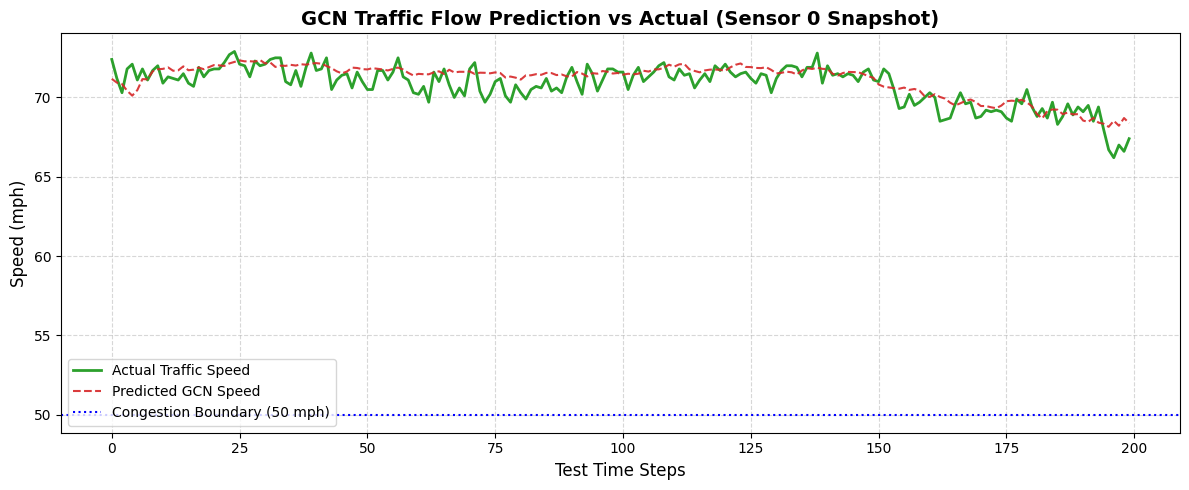

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Plot a slice of 200 time steps for Sensor 0
plt.plot(actuals_mph_c[:200, 0], label='Actual Traffic Speed', color='#2ca02c', linewidth=2)
plt.plot(preds_mph_c[:200, 0], label='Predicted GCN Speed', color='#d62728', linestyle='--', alpha=0.9)

# Draw the Congestion Threshold Boundary line
plt.axhline(y=50.0, color='blue', linestyle=':', label='Congestion Boundary (50 mph)')

plt.xlabel('Test Time Steps', fontsize=12)
plt.ylabel('Speed (mph)', fontsize=12)
plt.title('GCN Traffic Flow Prediction vs Actual (Sensor 0 Snapshot)', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
